## Marker genes

In [ ]:
sc.pl.umap(h5_rna, color=['SELL', 'IL7R', 'ITGAM'], size=40 , gene_symbols='gene_name', layer='log1p_counts')
# CD127 protein : gene IL7R (T cells subtype)
# CD62L protein : gene SELL (T cells subtype)
# CD11B protein: ITGAM gene: T cells do not express ITGAM (myloid)

In [ ]:
sc.pl.umap(h5_rna, color=['CD3D', 'IL7R', 'CD8A', 'CD8B',  'NKG7', 'GNLY', 'FGFBP2', 'FCGR3A', 'FCER1G'], size=40 , gene_symbols='gene_name', layer='log1p_counts')

In [ ]:
sc.pl.umap(h5_rna, color=[ 'ITGAX',   'CD14','FCGR3A' ], size=40 , gene_symbols='gene_name', layer='log1p_counts')
# CD11c protein: gene ITGAX -- DC 
# CD16 protein: gene FCGR3A -- NC monocytes

#### gamma-delta T cells 

In [ ]:
sc.pl.umap(h5_rna, color=[ 'TRDC',   'TRGC1','TRDV2', 'TRGV9'], size=40 , ncols=2, gene_symbols='gene_name', layer='log1p_counts') #

### pDCs and C14+ monocytes

In [ ]:
sc.pl.umap(h5_rna, color=[ 'CD14', 'IRF7', 'TLR9', 'TCF4', 'CLEC4C' ], size=40 ,ncols=3 ,gene_symbols='gene_name', layer='log1p_counts') #

####  MAIT/NK-T cells 

In [ ]:
sc.pl.umap(h5_rna, color=[ 'KLRG1',   'NCR3','KLRB1'], size=40 ,gene_symbols='gene_name', layer='log1p_counts') #

#### 

In [ ]:
sc.pl.umap(h5_rna, color=[ 'NCAM1',   'TBX21','IFNG', 'NKG7', 'XCL2', 'NCR1' ], size=40 ,ncols=3 ,gene_symbols='gene_name', layer='log1p_counts') #

#### Mono 

In [ ]:
sc.pl.umap(h5_rna, color=[ 'CD14',   'HLA-DRA', 'TNF', 'IL1B' ], size=40 ,ncols=3 ,gene_symbols='gene_name', layer='log1p_counts') #

In [ ]:
# cell-type idendification by Juliana

cluster_average_df = pd.DataFrame(index=h5_rna.var['gene_name'])

for c in h5_rna.obs['leiden_RNA_scVI'].unique():
    a = h5_rna[h5_rna.obs['leiden_RNA_scVI'] == c, :].layers['log1p_counts'].mean(axis=0)
    cluster_average_df[c] = np.asarray(a).flatten()
    
cluster_average_df.to_csv('HiJuliana_check_pbmc_rna_cluster_average_normalized_expression.csv')

cluster_average_df.head()

## Cell-type annotation from Julianaa

## Save average gene expression per cluster for Juliana to annotate cell-types

In [52]:
RNA_cell_clusters = h5_rna.obs['leiden_RNA_scVI'].unique()

cluster_gene_df = pd.DataFrame(index=h5_rna.var['gene_name'])

for c in RNA_cell_clusters:
    a = h5_rna[h5_rna.obs['leiden_RNA_scVI'] == c, :].layers['counts'].mean(axis=0)
    cluster_gene_df[c] = np.asarray(a).flatten()
    
save_file = os.path.join(entropy_dir, 'HiJuliana_check_pbmc_rna_cluster_average_raw_counts_UpdatedEntropyNormalization.csv')
cluster_gene_df.to_csv(save_file)

### Provicve clsuter to cell-type map

In [16]:
# Juliana's cell type annotation
# Juliana's cell type annotation
RNAcluster_celltype_map = {
'0': 'CD14+ Mo',
'1': 'CD4+CD8+ naive T cells',
'2': 'Tregs',
'3': 'B cells',
'4': 'ILC/NK cells',
'5': 'MAIT/NK T cells',
'6': 'gammaSignma T cells',
'7': 'Unknown',
'8': 'CD16+Mo',
'9': 'pDCs',
'10': 'Plasma cells (noisy)'
}
h5_rna.obs['celltype'] = h5_rna.obs['leiden_RNA_scVI'].map(RNAcluster_celltype_map)

## do NOT !!! delete 
## do NOT !!! delete 
## do NOT !!! delete 


# ## Save each cell-type's barcode 
# rna_cell_type_subdir = os.path.join(entropy_dir,  '_rna_cell_types')
# os.makedirs(rna_cell_type_subdir, exist_ok=True)

# #
# for cluster in h5_rna.obs['leiden_RNA_scVI'].unique():
#     write_file = 'RNAcluster_' + str(cluster) + '_df.csv' 
#     write_file_path = os.path.join(rna_cell_type_subdir, write_file)
#     h5_rna.obs.loc[h5_rna.obs['leiden_RNA_scVI'] == cluster, :].to_csv(write_file_path, index=False)
    
# # write cell-type mapping file
# celltype_map_file = os.path.join(rna_cell_type_subdir, 'RNAcluster_celltype_map.tsv')
# with open(celltype_map_file, 'w') as f:
#     for k, v in RNAcluster_celltype_map.items():
#         f.write(f"{k}\t{v}\n")

### plot to see cell-type fraction of reads in peaks (FRIP) for standard peak set and entropy peak set

Text(0.5, 0, 'Entropy value (log)')

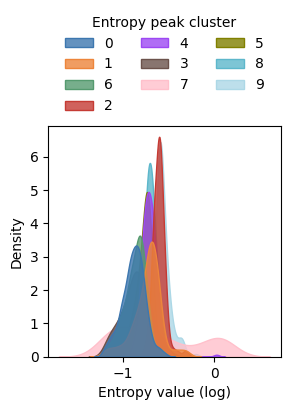

In [66]:
color_order = {'0': '#3d77af', '1': '#ed853b', '2': '#559a6f', '3': '#c53b34', '4': '#9d48f3',
             '5': '#6b524b', '6': 'pink', '7': 'olive', '8': '#5db7cb', '9': 'lightblue', 
                '10': '#f6a04d', '11': '#8fd18b', '12': 'lightcoral'}#, '13': 'lime'}
entropy_peak_cluster_order = h5_rna.obs['reorder_clusters_peakvi_highres_entropy'].cat.categories.tolist()
color_map = {k: color_order[str(i)] for i, k in enumerate(entropy_peak_cluster_order)}

fig, ax = plt.subplots(figsize=(3, 3))
kde = sns.kdeplot(data=h5_rna.obs, x='Entropy_log', hue='reorder_clusters_peakvi_highres_entropy', 
                  palette=color_map,
                  fill=True, 
                  ax=ax, alpha=0.8, common_norm=False)
sns.move_legend(
    kde, "lower center",
    bbox_to_anchor=(.5, 1), ncol=3, title='Entropy peak cluster', frameon=False
)

ax.set_xlabel('Entropy value (log)')


### Get Differentially accessible regions on Standard peak set, and Entropy peak set respectively

In [99]:
# NK-cells  
## NCR1  
# name: peak_19704
# location: chr19:54905933-54906212
# score: 835.0

# B cells
## MS4A1 
# name: peak_6326
# location: chr11:60455546-60455895
# score: 1000.0

# Activated CD8+ T cells
## IFNG
# name: peak_8656
# location: chr12:68159654-68160000
# score: 1000.0

# # T-cells 
## CD3D
# name: peak_7310
# location: chr11:118338531-118339381
# score: 1000.0
# name: peak_7311
# location: chr11:118344195-118344434
# score: 1000.0


# CD4+ T cells
## CD4
# name: peak_7743
# location: chr12:6789380-6789719
# score: 1000.0
# name: peak_7744
# location: chr12:6792633-6793231
# score: 1000.0

# T-reg CD4+ T cells
## FOXP3
# name: peak_37110
# location: chrX:49235357-49235915
# score: 940.0

# CD8+ T cells
## CD8A
# name: peak_20882
# location: chr2:86785468-86785833
# score: 1000.0
# name: peak_20883
# location: chr2:86786051-86786600
# score: 1000.0
# name: peak_20884
# location: chr2:86790583-86791587
# score: 644.0

# Mono
## TNF
# name: peak_21239
# location: chr2:112836678-112837043
# score: 1000.0
# Intermediate Mono
# name: peak_30585
# location: chr6:31575336-31575912
# score: 1000.0
## HLA-DRA
# name: peak_30637
# location: chr6:32439390-32440066
# score: 1000.0

# Classical Monocytes
## CD14
# name: peak_29379
# location: chr5:140631052-140631380
# score: 1000.0
# name: peak_29380
# location: chr5:140631995-140633887
# score: 748.0

# Dendritic Cells
## DNAI2
# name: peak_16318
# location: chr17:74280030-74280540
# score: 1000.0
# name: peak_16319
# location: chr17:74282729-74283423
# score: 905.0
# name: peak_16320
# location: chr17:74301243-74301427
# score: 1000.0

# with plt.rc_context({'figure.figsize': (5, 5)}):
#     sc.pl.umap(entropy_peak_plot, color=['clusters_peakvi_highres_entropy', 'leiden_RNA_scVI', \
#         'peak_19704', 'peak_6326', 'peak_8656', \
#             'peak_7310','peak_7311', 'peak_7743', 'peak_7744', \
#                 'peak_37110' , \
#                     'peak_20882', 'peak_20883', 'peak_20884', \
#                         'peak_21239' , \
#                             'peak_30585', 'peak_30637', \
#                                 'peak_29379', 'peak_29380', \
#                                     'peak_16318', 'peak_16319', 'peak_16320'], \
#         size=40 , ncols=3, layer=None) 